### Stage 3 Reasoning Agent (vLLM + Custom LangGraph + LLM-as-Judge)

### Overview

1. Cell 1 — dependency installation.
2. Cell 2 — LangSmith env vars + vLLM server launch.
3. Cell 3 — tool definitions (9 tools), dynamic schema injection, LLM setup.
4. Cell 4 — custom LangGraph `StateGraph` + runtime helpers (XML parsing, deterministic pre-check).
5. Cell 5 — validation: exact-match metrics + LLM-as-a-Judge evaluation.
6. Cell 6 — smoke tests (multi-step chaining, parallel calls, legacy).
7. Cell 7 — execution flow graph.

### Key parameters
Cell 2:
Configurable parameters for vLLM server and LangSmith tracing:
- `MODEL_ID`, `PORT`, `STARTUP_TIMEOUT_SEC`, `POLL_INTERVAL_SEC`
- `LANGCHAIN_TRACING_V2`, `LANGCHAIN_PROJECT`, `LANGCHAIN_API_KEY`

External server: set `BASE_URL` in Cell 3.

### Dataset
Path: `/content/validation_dataset_stage2.jsonl`.


In [1]:
# 1) Install dependencies
import sys

!{sys.executable} -m pip install -U -q vllm langgraph langchain-openai langchain-core langsmith pydantic requests psutil nest_asyncio networkx matplotlib graphviz

import nest_asyncio
nest_asyncio.apply()

print("[INFO] Dependencies installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899

In [ ]:
# 2) LangSmith tracing + vLLM backend server

import os
import sys
import time
import subprocess
import requests
import psutil
import gc
import warnings
os.environ["LANGCHAIN_API_KEY"] = "langchain api key" 

_langsmith_key = os.environ.get("LANGCHAIN_API_KEY", "").strip()
if _langsmith_key and not _langsmith_key.startswith("<"):
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_PROJECT"] = "Insurance_Agent_Stage3"
    os.environ["LANGCHAIN_ENDPOINT"] = "https://eu.api.smith.langchain.com"
    print("[INFO] LangSmith tracing enabled, project: Insurance_Agent_Stage3")
else:
    os.environ["LANGCHAIN_TRACING_V2"] = "false"
    print("[INFO] LangSmith tracing disabled (no valid LANGCHAIN_API_KEY).")
    print("[INFO] Set os.environ['LANGCHAIN_API_KEY'] = 'langchain_api_key")

# Protobuf compatibility
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

MODEL_ID = "Qwen/Qwen3-30B-A3B-Instruct-2507-FP8"
PORT = 8000
BASE_URL = f"http://localhost:{PORT}/v1"

# Startup wait settings
STARTUP_TIMEOUT_SEC = int(os.environ.get("VLLM_STARTUP_TIMEOUT_SEC", "900"))
POLL_INTERVAL_SEC = float(os.environ.get("VLLM_POLL_INTERVAL_SEC", "5"))



print("[INFO] Cleaning up old server processes...")
for proc in psutil.process_iter(["pid", "name"]):
    try:
        for conn in proc.connections(kind="inet"):
            if conn.laddr and conn.laddr.port == PORT:
                print(f"[INFO] Killing PID={proc.pid} name={proc.name()} on port {PORT}")
                proc.kill()
    except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.ZombieProcess):
        pass

# CUDA cache cleanup
try:
    import torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("[INFO] CUDA cache cleared.")
except Exception:
    pass

time.sleep(1)

# Tool call parser
raw_parser = os.environ.get("VLLM_TOOL_CALL_PARSER", "qwen3_xml").strip()
if raw_parser.lower() == "qwen":
    print("[WARN] VLLM_TOOL_CALL_PARSER='qwen' is invalid for vLLM 0.15.1. Mapping to 'qwen3_xml'.")
    raw_parser = "qwen3_xml"

tool_call_parser = raw_parser

cmd = [
    sys.executable,
    "-m",
    "vllm.entrypoints.openai.api_server",
    "--model",
    MODEL_ID,
    "--served-model-name",
    MODEL_ID,
    "--trust-remote-code",
    "--dtype",
    "auto",
    "--max-model-len",
    "8192",
    "--gpu-memory-utilization",
    "0.90",
    "--host",
    "0.0.0.0",
    "--port",
    str(PORT),
    "--enable-auto-tool-choice",
    "--tool-call-parser",
    tool_call_parser,
]

print("[INFO] Starting vLLM server...")
print("[INFO] Tool-call parser:", tool_call_parser)
print("[INFO] Startup timeout (sec):", STARTUP_TIMEOUT_SEC)
print("[INFO] Poll interval (sec):", POLL_INTERVAL_SEC)
print("[INFO] Command:", " ".join(cmd))

log_path = "vllm_server.log"
log_file = open(log_path, "w", encoding="utf-8")
process = subprocess.Popen(cmd, stdout=log_file, stderr=subprocess.STDOUT)

print(f"[INFO] Server PID={process.pid}")
print("[INFO] Waiting for /models to be available (can take a few minutes on first load)...")

start = time.time()
while True:
    if process.poll() is not None:
        print("[ERROR] vLLM process exited early.")
        print("[ERROR] Check vllm_server.log for details.")
        break

    try:
        r = requests.get(f"{BASE_URL}/models", timeout=5)
        if r.ok:
            print("[INFO] vLLM is online.")
            print("[INFO] BASE_URL:", BASE_URL)
            print("[INFO] /models (short):", r.text[:300])
            break
    except requests.exceptions.RequestException:
        pass

    if time.time() - start > STARTUP_TIMEOUT_SEC:
        print("[ERROR] Timeout waiting for vLLM server.")
        print("[ERROR] Check vllm_server.log")
        process.kill()
        break

    time.sleep(POLL_INTERVAL_SEC)
    print(".", end="", flush=True)


[INFO] LangSmith tracing enabled, project: Insurance_Agent_Stage3
[INFO] Cleaning up old server processes...
[INFO] CUDA cache cleared.
[INFO] Starting vLLM server...
[INFO] Tool-call parser: qwen3_xml
[INFO] Startup timeout (sec): 900
[INFO] Poll interval (sec): 5.0
[INFO] Command: /usr/bin/python3 -m vllm.entrypoints.openai.api_server --model Qwen/Qwen3-30B-A3B-Instruct-2507-FP8 --served-model-name Qwen/Qwen3-30B-A3B-Instruct-2507-FP8 --trust-remote-code --dtype auto --max-model-len 8192 --gpu-memory-utilization 0.90 --host 0.0.0.0 --port 8000 --enable-auto-tool-choice --tool-call-parser qwen3_xml
[INFO] Server PID=1256
[INFO] Waiting for /models to be available (can take a few minutes on first load)...
.....................................................[INFO] vLLM is online.
[INFO] BASE_URL: http://localhost:8000/v1
[INFO] /models (short): {"object":"list","data":[{"id":"Qwen/Qwen3-30B-A3B-Instruct-2507-FP8","object":"model","created":1772679958,"owned_by":"vllm","root":"Qwen/Qwen

In [ ]:
# 3) Tools (9 total) + LLM setup (no bind_tools — tool schemas injected into prompt)

from __future__ import annotations

from typing import Any, Dict, List, Optional
from datetime import date
import re
import json

from pydantic import BaseModel, Field
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

# Use vLLM server from cell 2
MODEL_ID = "Qwen/Qwen3-30B-A3B-Instruct-2507-FP8"
BASE_URL = "http://localhost:8000/v1"
API_KEY = "EMPTY"  # vLLM local server needs no real key


# --- Dynamic tool schema formatter ---

def format_tool_schemas_for_prompt(tool_list: list) -> str:
    """Format LangChain tool schemas into a JSON string for system prompt injection.
    This bypasses vLLM's broken bind_tools/qwen3_xml parser by letting
    the model see available tools directly in the system message.
    """
    schemas: List[Dict[str, Any]] = []
    for t in tool_list:
        schema_cls = getattr(t, "args_schema", None)
        if schema_cls:
            json_schema = schema_cls.model_json_schema()
            properties = json_schema.get("properties", {})
            required = json_schema.get("required", [])
            params: Dict[str, Any] = {}
            for pname, prop in properties.items():
                params[pname] = {
                    "type": prop.get("type", "string"),
                    "description": prop.get("description", ""),
                    "required": pname in required,
                }
        else:
            params = {}
        schemas.append({
            "name": t.name,
            "description": t.description or "",
            "parameters": params,
        })
    return json.dumps(schemas, indent=2, ensure_ascii=False)


# --- Base system prompt (rules only) ---

_BASE_SYSTEM_PROMPT: str = (
    """"Вы — профессиональный ИИ-ассистент страховой компании. Ваша задача — помогать пользователям, рассчитывать страховки и проверять полисы, используя доступные инструменты.

### ВАЖНЫЕ ПРАВИЛА ИСПОЛЬЗОВАНИЯ ИНСТРУМЕНТОВ (СТРОГО ДЛЯ ВЫПОЛНЕНИЯ):
1. ТОЛЬКО XML ФОРМАТ: Если у вас есть все данные для использования инструмента, вы ОБЯЗАНЫ вывести ТОЛЬКО следующий XML-блок. Никаких markdown-кавычек.
<tool_call>
{"name": "имя_инструмента", "arguments": {"аргумент1": "значение1"}}
</tool_call>

2. НИКАКИХ ЛИШНИХ СЛОВ (ZERO FILLER): НИКОГДА не комментируйте свои действия до вызова инструмента. Не пишите "Проверяю данные..." или "Сейчас рассчитаю...". Если данные есть — сразу выдавайте <tool_call> и останавливайтесь.

3. МНОГОШАГОВЫЕ ВЫЗОВЫ (ПРАВИЛО GOLDEN ID):
Если для инструмента нужен уникальный ID (например, `policy_id`), а пользователь дал только имя и телефон, СНАЧАЛА вызовите `search_client_policy`. Дождитесь ответа системы (<tool_result>) с ID, и ТОЛЬКО ЗАТЕМ делайте второй <tool_call> с этим ID.

4. ПАРАЛЛЕЛЬНЫЕ ВЫЗОВЫ (АСИНХРОННОСТЬ):
Если пользователь просит две разные вещи в одном сообщении (например, "Рассчитай страховку И расскажи про шаги при ДТП"), вы ОБЯЗАНЫ выдать несколько блоков <tool_call> подряд в одном ответе.

5. ГИБКОСТЬ ФОРМУЛИРОВОК (FUZZY MATCHING):
Пользователь может использовать синонимы. Например, "апартаменты" или "квартира" — это одно и то же. Адаптируйте входные данные под требования параметров инструмента.
6. ЕСЛИ ДАННЫХ НЕ ХВАТАЕТ:
Если для работы инструмента требуются параметры, а пользователь их не указал — ЗАДАЙТЕ УТОЧНЯЮЩИЙ ВОПРОС простым текстом. Категорически запрещено выдумывать данные или вызывать инструмент наугад.
### ПРИМЕРЫ ПРАВИЛЬНОГО ПОВЕДЕНИЯ (FEW-SHOT):

Пример 1: Многошаговость (Golden ID)
User: "Можете проверить статус моего полиса? Меня зовут Иван Иванов, телефон +79991234567."
Agent:
<tool_call>
{"name": "search_client_policy", "arguments": {"full_name": "Иван Иванов", "phone_number": "+79991234567"}}
</tool_call>
System:
<tool_result>
Name: search_client_policy
Result: Found policy_id: POL-10045
</tool_result>
Agent:
<tool_call>
{"name": "get_policy_details", "arguments": {"policy_id": "POL-10045"}}
</tool_call>
System:
<tool_result>
Name: get_policy_details
Result: Status: Active, Type: OSAGO, Car: Toyota Camry 2020
</tool_result>
Agent: Ваш полис ОСАГО (номер POL-10045) на автомобиль Toyota Camry 2020 активен.

Пример 2: Немедленное выполнение (БЕЗ лишних слов)
User: "Рассчитай ОСАГО: 140 л.с., возраст 29, стаж 7 лет, регион Москва, стоимость авто 2200000, 2019 год, ДТП 1, пробег 18000, 1 доп водитель, охрана да, телематика нет, франшиза да."
Agent:
<tool_call>
{"name": "calculate_osago_quote", "arguments": {"engine_power_hp": 140, "driver_age": 29, "driving_experience_years": 7, "region": "Москва", "vehicle_market_value": 2200000, "vehicle_year": 2019, "accidents_last_3y": 1, "yearly_mileage_km": 18000, "additional_drivers_count": 1, "has_secured_parking": true, "has_telematics": false, "has_deductible": true}}
</tool_call>

Пример 3: Параллельные вызовы
User: "Мне нужна туристическая страховка в Турцию на 10 дней, возраст 35, покрытие 30000 евро. И ещё подскажите, какие шаги при медицинском случае в поездке?"
Agent:
<tool_call>
{"name": "calculate_travel_insurance", "arguments": {"days": 10, "country": "Турция", "traveler_age": 35, "coverage_eur": 30000}}
</tool_call>
<tool_call>
{"name": "get_claim_steps", "arguments": {"event_type": "медицина_в_поездке"}}
</tool_call>

Вам доступны следующие инструменты:
"""
)


# --- In-memory stores ---

CALLBACK_REQUESTS: List[Dict[str, str]] = []
SUPPORT_TICKETS: List[Dict[str, str]] = []

# Simulated policy database for multi-step tool chaining
POLICY_DB: Dict[str, Dict[str, str]] = {
    "POL-10045": {
        "policy_id": "POL-10045",
        "full_name": "Иван Иванов",
        "phone": "+79991234567",
        "product": "OSAGO",
        "status": "active",
        "vehicle": "Toyota Camry 2020",
        "premium_rub": "8340",
        "valid_until": "2027-03-15",
    },
    "POL-20078": {
        "policy_id": "POL-20078",
        "full_name": "Мария Петрова",
        "phone": "+79005556677",
        "product": "Property",
        "status": "active",
        "address": "Москва, ул. Ленина 12, кв. 45",
        "premium_rub": "24500",
        "valid_until": "2026-11-01",
    },
    "POL-30012": {
        "policy_id": "POL-30012",
        "full_name": "Алексей Сидоров",
        "phone": "+79161112233",
        "product": "Travel",
        "status": "expired",
        "destination": "Thailand",
        "premium_rub": "3900",
        "valid_until": "2025-08-20",
    },
}

# Reverse index: (normalized_name, phone) -> policy_id
POLICY_INDEX: Dict[str, str] = {}
for _pid, _rec in POLICY_DB.items():
    _key = (_rec["full_name"].strip().lower(), _rec["phone"].strip())
    POLICY_INDEX[str(_key)] = _pid


def is_valid_phone(phone: str) -> bool:
    return bool(re.fullmatch(r"[+]?\d{10,15}", phone.replace(" ", "")))


# --- Stage 3 tools: multi-step policy lookup ---

class SearchClientPolicyArgs(BaseModel):
    full_name: str = Field(..., description="Client full name")
    phone_number: str = Field(..., description="Client phone number, 10-15 digits")


@tool(args_schema=SearchClientPolicyArgs)
def search_client_policy(full_name: str, phone_number: str) -> str:
    """Search for a client policy by name and phone. Returns policy_id if found."""
    try:
        if not full_name.strip():
            return "[ERROR] full_name is required."
        if not is_valid_phone(phone_number):
            return "[ERROR] Invalid phone format."

        lookup_key = str((full_name.strip().lower(), phone_number.strip()))
        policy_id = POLICY_INDEX.get(lookup_key)

        if policy_id:
            return f"[TOOL] Policy found: {policy_id}"

        # Fallback: partial name match
        name_lower = full_name.strip().lower()
        for pid, rec in POLICY_DB.items():
            if name_lower in rec["full_name"].lower():
                return f"[TOOL] Policy found: {pid}"

        return "[TOOL] No policy found for this client."
    except Exception as e:
        return f"[ERROR] search_client_policy: {e}"


class GetPolicyDetailsArgs(BaseModel):
    policy_id: str = Field(..., description="Policy ID, e.g. POL-10045")


@tool(args_schema=GetPolicyDetailsArgs)
def get_policy_details(policy_id: str) -> str:
    """Retrieve full policy details by policy_id."""
    try:
        if not policy_id.strip():
            return "[ERROR] policy_id is required."

        record = POLICY_DB.get(policy_id.strip())
        if not record:
            return f"[TOOL] Policy {policy_id} not found in database."

        lines = [f"[TOOL] Policy details for {policy_id}:"]
        for key, value in record.items():
            lines.append(f"  {key}: {value}")
        return "\n".join(lines)
    except Exception as e:
        return f"[ERROR] get_policy_details: {e}"


# --- Existing tools (unchanged logic) ---

class OsagoQuoteArgs(BaseModel):
    engine_power_hp: int = Field(..., description="Engine power, HP")
    driver_age: int = Field(..., description="Driver age, years")
    driving_experience_years: int = Field(..., description="Driving experience, years")
    region: str = Field(..., description="Operating region")
    vehicle_market_value: float = Field(..., description="Vehicle market value, RUB")
    vehicle_year: int = Field(..., description="Vehicle year")
    accidents_last_3y: int = Field(..., description="Accidents in last 3 years")
    yearly_mileage_km: int = Field(..., description="Yearly mileage, km")
    additional_drivers_count: int = Field(..., description="Additional drivers count")
    has_secured_parking: bool = Field(..., description="Has secured parking")
    has_telematics: bool = Field(..., description="Has telematics device")
    has_deductible: bool = Field(..., description="Has deductible")


@tool(args_schema=OsagoQuoteArgs)
def calculate_osago_quote(
    engine_power_hp: int,
    driver_age: int,
    driving_experience_years: int,
    region: str,
    vehicle_market_value: float,
    vehicle_year: int,
    accidents_last_3y: int,
    yearly_mileage_km: int,
    additional_drivers_count: int,
    has_secured_parking: bool,
    has_telematics: bool,
    has_deductible: bool,
) -> str:
    """Calculate estimated OSAGO premium with extended parameters (12 fields)."""
    try:
        if engine_power_hp <= 0:
            return "[ERROR] engine_power_hp must be > 0."
        if driver_age < 18:
            return "[ERROR] driver_age must be >= 18."
        if driving_experience_years < 0:
            return "[ERROR] driving_experience_years must be >= 0."
        if not region.strip():
            return "[ERROR] region is required."
        if vehicle_market_value <= 0:
            return "[ERROR] vehicle_market_value must be > 0."
        if vehicle_year < 1980:
            return "[ERROR] vehicle_year looks incorrect."
        if accidents_last_3y < 0:
            return "[ERROR] accidents_last_3y must be >= 0."
        if yearly_mileage_km < 0:
            return "[ERROR] yearly_mileage_km must be >= 0."
        if additional_drivers_count < 0:
            return "[ERROR] additional_drivers_count must be >= 0."

        base_rate = 5200.0

        power_factor = 1.0 if engine_power_hp <= 100 else 1.2 if engine_power_hp <= 150 else 1.35
        age_factor = 1.25 if driver_age < 23 else 1.0
        experience_factor = 1.25 if driving_experience_years < 3 else 1.0
        region_factor = 1.2 if region.strip().lower() in ["москва", "msk", "moscow", "спб", "saint petersburg"] else 1.0
        accident_factor = 1.0 + min(accidents_last_3y * 0.12, 0.48)
        mileage_factor = 1.1 if yearly_mileage_km > 25000 else 1.0
        additional_drivers_factor = 1.0 + min(additional_drivers_count * 0.03, 0.15)
        vehicle_age_factor = 1.08 if (date.today().year - vehicle_year) > 12 else 1.0

        secured_parking_discount = 0.97 if has_secured_parking else 1.0
        telematics_discount = 0.95 if has_telematics else 1.0
        deductible_discount = 0.93 if has_deductible else 1.0

        premium = (
            base_rate
            * power_factor
            * age_factor
            * experience_factor
            * region_factor
            * accident_factor
            * mileage_factor
            * additional_drivers_factor
            * vehicle_age_factor
            * secured_parking_discount
            * telematics_discount
            * deductible_discount
        )

        return f"[TOOL] Estimated OSAGO premium: {premium:.0f} RUB/year."
    except Exception as e:
        return f"[ERROR] calculate_osago_quote: {e}"


class PropertyInsuranceQuoteArgs(BaseModel):
    property_type: str = Field(..., description="Object type: apartment/house/studio")
    city: str = Field(..., description="City")
    area_m2: float = Field(..., description="Area, m2")
    year_built: int = Field(..., description="Year built")
    market_value_rub: float = Field(..., description="Market value, RUB")
    floor: int = Field(..., description="Floor")
    has_fire_alarm: bool = Field(..., description="Has fire alarm")
    has_water_leak_sensor: bool = Field(..., description="Has water leak sensor")
    has_security_system: bool = Field(..., description="Has security system")
    insured_risks_count: int = Field(..., description="Number of insured risks")
    deductible_rub: float = Field(..., description="Deductible, RUB")
    short_term_rentals: bool = Field(..., description="Used for short-term rentals")


@tool(args_schema=PropertyInsuranceQuoteArgs)
def calculate_property_insurance_quote(
    property_type: str,
    city: str,
    area_m2: float,
    year_built: int,
    market_value_rub: float,
    floor: int,
    has_fire_alarm: bool,
    has_water_leak_sensor: bool,
    has_security_system: bool,
    insured_risks_count: int,
    deductible_rub: float,
    short_term_rentals: bool,
) -> str:
    """Calculate estimated property insurance premium with extended parameters (12 fields)."""
    try:
        if not property_type.strip():
            return "[ERROR] property_type is required."
        if not city.strip():
            return "[ERROR] city is required."
        if area_m2 <= 0:
            return "[ERROR] area_m2 must be > 0."
        if year_built < 1900:
            return "[ERROR] year_built looks incorrect."
        if market_value_rub <= 0:
            return "[ERROR] market_value_rub must be > 0."
        if floor < -2:
            return "[ERROR] floor looks incorrect."
        if insured_risks_count <= 0:
            return "[ERROR] insured_risks_count must be > 0."
        if deductible_rub < 0:
            return "[ERROR] deductible_rub must be >= 0."

        base_rate = 0.0028 * market_value_rub
        area_factor = 1.0 + min(max((area_m2 - 40) / 300, -0.2), 0.6)
        age_factor = 1.15 if (date.today().year - year_built) > 45 else 1.0
        floor_factor = 1.08 if floor in [1, -1, 0] else 1.0
        risks_factor = 1.0 + min(insured_risks_count * 0.05, 0.35)
        rentals_factor = 1.18 if short_term_rentals else 1.0

        discount_fire = 0.95 if has_fire_alarm else 1.0
        discount_water = 0.96 if has_water_leak_sensor else 1.0
        discount_security = 0.95 if has_security_system else 1.0
        deductible_factor = max(0.8, 1.0 - min(deductible_rub / 500000, 0.2))

        premium = (
            base_rate
            * area_factor
            * age_factor
            * floor_factor
            * risks_factor
            * rentals_factor
            * discount_fire
            * discount_water
            * discount_security
            * deductible_factor
        )

        return f"[TOOL] Estimated property insurance premium: {premium:.0f} RUB/year."
    except Exception as e:
        return f"[ERROR] calculate_property_insurance_quote: {e}"


class TravelInsuranceArgs(BaseModel):
    days: int = Field(..., description="Trip duration, days")
    country: str = Field(..., description="Destination country")
    sports_risk: bool = Field(False, description="Include sports risks")
    traveler_age: int = Field(..., description="Traveler age")
    coverage_eur: int = Field(..., description="Coverage amount, EUR")


@tool(args_schema=TravelInsuranceArgs)
def calculate_travel_insurance(
    days: int,
    country: str,
    sports_risk: bool = False,
    traveler_age: int = 30,
    coverage_eur: int = 30000,
) -> str:
    """Calculate estimated travel insurance premium."""
    try:
        if days <= 0:
            return "[ERROR] days must be > 0."
        if not country.strip():
            return "[ERROR] country is required."
        if traveler_age < 0:
            return "[ERROR] traveler_age is invalid."
        if coverage_eur <= 0:
            return "[ERROR] coverage_eur must be > 0."

        base_rate = 130.0
        sports_factor = 1.8 if sports_risk else 1.0
        age_factor = 1.25 if traveler_age >= 65 else 1.0
        coverage_factor = 1.2 if coverage_eur >= 50000 else 1.0

        price = days * base_rate * sports_factor * age_factor * coverage_factor
        return f"[TOOL] Estimated travel insurance premium: {price:.0f} RUB."
    except Exception as e:
        return f"[ERROR] calculate_travel_insurance: {e}"


class DocumentChecklistArgs(BaseModel):
    product: str = Field(..., description="Product type: osago/kasko/travel/property")


@tool(args_schema=DocumentChecklistArgs)
def get_document_checklist(product: str) -> str:
    """Return document checklist by insurance product type."""
    try:
        normalized = product.strip().lower()
        documents = {
            "осаго": ["Паспорт", "ВУ", "СТС", "Данные VIN/госномер"],
            "каско": ["Паспорт", "ВУ", "СТС", "Фото авто"],
            "путешествия": ["Паспорт", "Даты поездки", "Страна"],
            "имущество": ["Паспорт", "Адрес объекта", "Документ собственности"],
        }
        if normalized not in documents:
            return "[ERROR] Unknown product. Use: осаго/каско/путешествия/имущество."
        return "[TOOL] Required documents: " + ", ".join(documents[normalized])
    except Exception as e:
        return f"[ERROR] get_document_checklist: {e}"


class ClaimStepsArgs(BaseModel):
    event_type: str = Field(..., description="Event type: дтп/имущество/медицина_в_поездке")


@tool(args_schema=ClaimStepsArgs)
def get_claim_steps(event_type: str) -> str:
    """Return short claim handling steps by event type."""
    try:
        normalized = event_type.strip().lower()
        if normalized == "дтп":
            return "[TOOL] Steps: 1) Ensure safety 2) Take photos/video 3) Call services if needed 4) File a claim."
        if normalized == "имущество":
            return "[TOOL] Steps: 1) Document damage 2) Prevent further damage 3) Contact support 4) Submit documents."
        if normalized == "медицина_в_поездке":
            return "[TOOL] Steps: 1) Contact assistance 2) Keep receipts and reports 3) Submit full document package."
        return "[ERROR] Unknown event type. Use: дтп/имущество/медицина_в_поездке."
    except Exception as e:
        return f"[ERROR] get_claim_steps: {e}"


class CallbackRequestArgs(BaseModel):
    full_name: str = Field(..., description="Client full name")
    phone: str = Field(..., description="Phone, 10-15 digits")
    topic: str = Field(..., description="Request topic")


@tool(args_schema=CallbackRequestArgs)
def create_callback_request(full_name: str, phone: str, topic: str) -> str:
    """Create callback request."""
    try:
        if not full_name.strip():
            return "[ERROR] full_name is required."
        if not is_valid_phone(phone):
            return "[ERROR] Invalid phone format."
        if not topic.strip():
            return "[ERROR] topic is required."

        request_id = len(CALLBACK_REQUESTS) + 1
        CALLBACK_REQUESTS.append(
            {
                "id": str(request_id),
                "full_name": full_name.strip(),
                "phone": phone.strip(),
                "topic": topic.strip(),
                "date": date.today().isoformat(),
            }
        )
        return f"[TOOL] Callback request created. ID={request_id}."
    except Exception as e:
        return f"[ERROR] create_callback_request: {e}"


class SupportTicketArgs(BaseModel):
    customer_name: str = Field(..., description="Client name")
    contact_phone: str = Field(..., description="Client phone")
    topic: str = Field(..., description="Request topic")
    urgency: str = Field(..., description="low/medium/high")
    description: str = Field(..., description="Problem description")


@tool(args_schema=SupportTicketArgs)
def create_support_ticket(
    customer_name: str,
    contact_phone: str,
    topic: str,
    urgency: str,
    description: str,
) -> str:
    """Create support ticket for human advisor follow-up."""
    try:
        if not customer_name.strip():
            return "[ERROR] customer_name is required."
        if not is_valid_phone(contact_phone):
            return "[ERROR] Invalid contact_phone format."
        if not topic.strip():
            return "[ERROR] topic is required."
        if urgency.strip().lower() not in ["low", "medium", "high"]:
            return "[ERROR] urgency must be low/medium/high."
        if len(description.strip()) < 10:
            return "[ERROR] description is too short."

        ticket_id = len(SUPPORT_TICKETS) + 1
        SUPPORT_TICKETS.append(
            {
                "id": str(ticket_id),
                "customer_name": customer_name.strip(),
                "contact_phone": contact_phone.strip(),
                "topic": topic.strip(),
                "urgency": urgency.strip().lower(),
                "description": description.strip(),
                "date": date.today().isoformat(),
            }
        )
        return f"[TOOL] Support ticket created. ID={ticket_id}."
    except Exception as e:
        return f"[ERROR] create_support_ticket: {e}"


# --- Build tools list, schemas, and final SYSTEM_PROMPT ---

tools = [
    search_client_policy,
    get_policy_details,
    calculate_osago_quote,
    calculate_property_insurance_quote,
    calculate_travel_insurance,
    get_document_checklist,
    get_claim_steps,
    create_callback_request,
    create_support_ticket,
]

TOOL_SCHEMAS_TEXT: str = format_tool_schemas_for_prompt(tools)

SYSTEM_PROMPT: str = (
    _BASE_SYSTEM_PROMPT
    + "\n\n## Available Tools\n\n"
    + TOOL_SCHEMAS_TEXT
    + "\n\n## Tool Call Format\n\n"
    + "To call a tool, output one or more XML blocks:\n"
    + "<tool_call>\n"
    + '{"name": "tool_name", "arguments": {"arg1": "value1"}}\n'
    + "</tool_call>\n\n"
    + "You may output multiple <tool_call> blocks in one response for parallel execution.\n"
    + "After receiving tool results in <tool_result> tags, use them to compose your final answer.\n"
    + "When you have the final answer, respond normally in Russian WITHOUT any <tool_call> blocks.\n"
)

# --- LLM (raw, no bind_tools) ---

llm = ChatOpenAI(
    model=MODEL_ID,
    base_url=BASE_URL,
    api_key=API_KEY,
    temperature=0.1,
)

# Tool registry for direct execution
TOOL_REGISTRY: Dict[str, Any] = {t.name: t for t in tools}

print("[INFO] Tools available to the model:")
for t in tools:
    schema = getattr(t, "args_schema", None)
    fields = list(getattr(schema, "model_fields", {}).keys()) if schema else []
    print(f"  - {t.name}({', '.join(fields)})")
print(f"[INFO] Tool schemas injected into system prompt ({len(TOOL_SCHEMAS_TEXT)} chars)")
print(f"[INFO] LLM created (raw mode, no bind_tools). Total tools: {len(tools)}")

[INFO] Tools available to the model:
  - search_client_policy(full_name, phone_number)
  - get_policy_details(policy_id)
  - calculate_osago_quote(engine_power_hp, driver_age, driving_experience_years, region, vehicle_market_value, vehicle_year, accidents_last_3y, yearly_mileage_km, additional_drivers_count, has_secured_parking, has_telematics, has_deductible)
  - calculate_property_insurance_quote(property_type, city, area_m2, year_built, market_value_rub, floor, has_fire_alarm, has_water_leak_sensor, has_security_system, insured_risks_count, deductible_rub, short_term_rentals)
  - calculate_travel_insurance(days, country, sports_risk, traveler_age, coverage_eur)
  - get_document_checklist(product)
  - get_claim_steps(event_type)
  - create_callback_request(full_name, phone, topic)
  - create_support_ticket(customer_name, contact_phone, topic, urgency, description)
[INFO] Tool schemas injected into system prompt (6838 chars)
[INFO] LLM created (raw mode, no bind_tools). Total tools: 9

In [ ]:
# 4) Custom LangGraph StateGraph + runtime helpers (no file logging — LangSmith traces)

from typing import List, Any, Dict, Optional, Sequence, Annotated, TypedDict
from pathlib import Path
import json
import re
import ast

from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Dataset path
DATASET_PATH: str = str(Path("/content/validation_dataset_stage2.jsonl"))
print(f"[INFO] Dataset path: {DATASET_PATH}")


# --- Tool call parsing utilities ---

def best_effort_parse_obj(text: str) -> Dict[str, Any]:
    """Try JSON then ast.literal_eval, fallback to raw dict."""
    text = text.strip()
    try:
        return json.loads(text)
    except Exception:
        pass
    try:
        obj = ast.literal_eval(text)
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass
    return {"raw": text}


def _strip_llm_artifacts(text: str) -> str:
    """Remove markdown fences, <think> blocks, and other Qwen3 artifacts."""
    # 1) Strip <think>…</think> reasoning blocks (Qwen3 thinking mode)
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    # 2) Remove markdown code fences that wrap tool calls
    #    e.g.  ```xml\n<tool_call>...   or  ```\n<tool_call>...
    text = re.sub(r"```(?:xml|json|text)?\s*", "", text)
    # 3) Remove stray backtick lines
    text = re.sub(r"^`{1,3}\s*$", "", text, flags=re.MULTILINE)
    return text


def parse_xml_tool_calls(text: str) -> List[Dict[str, Any]]:
    """Extract tool calls from <tool_call>…</tool_call> XML blocks.

    Aggressively fault-tolerant:
    - Strips markdown fences (```xml … ```)
    - Strips <think>…</think> blocks
    - Handles whitespace/newline variations
    - Falls back to brace-matching if XML tags are malformed
    """
    text = _strip_llm_artifacts(text)

    calls: List[Dict[str, Any]] = []

    # Primary: clean <tool_call>{…}</tool_call> extraction
    blocks = re.findall(
        r"<tool_call>\s*(\{.*?\})\s*</tool_call>", text, flags=re.DOTALL
    )
    for block in blocks:
        parsed = best_effort_parse_obj(block)
        if isinstance(parsed, dict) and "raw" not in parsed:
            calls.append(parsed)

    if calls:
        return calls

    # Fallback 1: unclosed <tool_call> — grab JSON after the tag
    fallback_blocks = re.findall(
        r"<tool_call>\s*(\{.*?\})", text, flags=re.DOTALL
    )
    for block in fallback_blocks:
        parsed = best_effort_parse_obj(block)
        if isinstance(parsed, dict) and "raw" not in parsed:
            calls.append(parsed)

    if calls:
        return calls

    # Fallback 2: no XML tags at all — look for bare {"name": …, "arguments": …}
    bare = re.findall(
        r'(\{\s*"name"\s*:.*?"arguments"\s*:\s*\{.*?\}\s*\})',
        text, flags=re.DOTALL,
    )
    for block in bare:
        parsed = best_effort_parse_obj(block)
        if isinstance(parsed, dict) and parsed.get("name"):
            calls.append(parsed)

    return calls


def extract_tool_calls_from_messages(messages: List[Any]) -> List[Dict[str, Any]]:
    """Pull tool_calls from LangChain message objects."""
    extracted: List[Dict[str, Any]] = []
    for message in messages:
        tool_calls = getattr(message, "tool_calls", None)
        if tool_calls:
            extracted.extend(tool_calls)
        additional_kwargs = getattr(message, "additional_kwargs", None)
        if isinstance(additional_kwargs, dict) and additional_kwargs.get("tool_calls"):
            extracted.extend(additional_kwargs["tool_calls"])
    return extracted


def normalize_tool_call(tool_call: Dict[str, Any]) -> Dict[str, Any]:
    """Normalize tool call dict to {name, arguments}."""
    name = tool_call.get("name") or tool_call.get("tool_name")
    if not name and isinstance(tool_call.get("function"), dict):
        name = tool_call["function"].get("name")

    arguments = (
        tool_call.get("arguments")
        or tool_call.get("args")
        or tool_call.get("parameters")
        or tool_call.get("input")
    )
    if arguments is None and isinstance(tool_call.get("function"), dict):
        arguments = tool_call["function"].get("arguments")
    if arguments is None:
        arguments = {}
    if isinstance(arguments, str):
        parsed = best_effort_parse_obj(arguments)
        arguments = parsed if isinstance(parsed, dict) else {"raw": arguments}
    if not isinstance(arguments, dict):
        arguments = {"raw": str(arguments)}

    return {"name": name, "arguments": arguments}


def execute_tool_calls(tool_calls: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    """Execute a list of tool calls against the registry."""
    results: List[Dict[str, Any]] = []
    for tool_call in tool_calls:
        normalized = normalize_tool_call(tool_call)
        name, arguments = normalized["name"], normalized["arguments"]

        if not name:
            results.append({"name": None, "args": arguments, "content": "[ERROR] Could not parse tool name."})
            continue

        tool_obj = TOOL_REGISTRY.get(name)
        if not tool_obj:
            results.append({"name": name, "args": arguments, "content": f"[ERROR] Unknown tool: {name}"})
            continue

        try:
            content = tool_obj.invoke(arguments)
        except Exception as e:
            content = f"[ERROR] Tool execution failed: {e}"

        results.append({"name": name, "args": arguments, "content": content})
    return results


def final_text_from_tool_results(results: List[Dict[str, Any]]) -> str:
    """Combine tool results into a single text block."""
    texts: List[str] = []
    for result in results:
        txt = str(result["content"]).replace("[TOOL] ", "").strip()
        texts.append(txt)
    return "\n".join(texts).strip()


# --- Deterministic pre-check (OSAGO / Property only) ---

def format_missing_fields(missing_fields: List[str]) -> str:
    lines = ["Не хватает данных для расчёта. Уточните, пожалуйста:"]
    lines.extend([f"- {item}" for item in missing_fields])
    return "\n".join(lines)


def parse_bool_ru(text: str, positive_words: List[str], negative_words: List[str]) -> Optional[bool]:
    t = text.lower()
    if any(w in t for w in positive_words):
        return True
    if any(w in t for w in negative_words):
        return False
    return None


def extract_osago_params(text: str) -> Dict[str, Any]:
    t = text.lower()
    params: Dict[str, Any] = {}

    patterns = {
        "engine_power_hp": r"(мощн(?:ость)?\s*[:=]?\s*(\d{2,3}))|((\d{2,3})\s*л\.с)",
        "driver_age": r"возраст\s*[:=]?\s*(\d{2})",
        "driving_experience_years": r"стаж\s*[:=]?\s*(\d{1,2})",
        "vehicle_market_value": r"стоим(?:ость)?\s*(?:авто)?\s*[:=]?\s*(\d{5,9})",
        "vehicle_year": r"год(?:\s*выпуска)?\s*[:=]?\s*(20\d{2}|19\d{2})",
        "accidents_last_3y": r"дтп(?:\s*за\s*3\s*года)?\s*[:=]?\s*(\d{1,2})",
        "yearly_mileage_km": r"пробег\s*[:=]?\s*(\d{3,6})",
        "additional_drivers_count": r"доп\s*(?:водител(?:ей|я)|)\s*[:=]?\s*(\d{1,2})",
    }

    for key, pattern in patterns.items():
        match = re.search(pattern, t)
        if match:
            nums = [g for g in match.groups() if g and g.isdigit()]
            if nums:
                value = int(nums[-1])
                params[key] = float(value) if key == "vehicle_market_value" else value

    city_match = re.search(r"регион\s*[:=]?\s*([а-яa-z\- ]{3,30})", t)
    if city_match:
        params["region"] = city_match.group(1).strip().title()
    else:
        for city in ["москва", "санкт-петербург", "спб", "казань", "екатеринбург", "новосибирск", "самара", "уфа", "краснодар"]:
            if city in t:
                params["region"] = city.title()
                break

    parking = parse_bool_ru(t, ["парковка: да", "парковка да", "охраняемая парковка: да", "охраняемая парковка да"], ["парковка: нет", "парковка нет", "охраняемая парковка: нет", "охраняемая парковка нет"])
    telematics = parse_bool_ru(t, ["телематика: да", "телематика да"], ["телематика: нет", "телематика нет"])
    deductible = parse_bool_ru(t, ["франшиза: да", "франшиза да"], ["франшиза: нет", "франшиза нет"])

    if parking is not None:
        params["has_secured_parking"] = parking
    if telematics is not None:
        params["has_telematics"] = telematics
    if deductible is not None:
        params["has_deductible"] = deductible

    return params


def extract_property_params(text: str) -> Dict[str, Any]:
    t = text.lower()
    params: Dict[str, Any] = {}

    type_map = {"квартира": "квартира", "дом": "дом", "апартамент": "апартаменты"}
    for token, normalized in type_map.items():
        if token in t:
            params["property_type"] = normalized
            break

    city_match = re.search(r"город\s*[:=]?\s*([а-яa-z\- ]{3,30})", t)
    if city_match:
        params["city"] = city_match.group(1).strip().title()

    num_patterns = {
        "area_m2": r"площад[ьи]\s*[:=]?\s*(\d{2,4})",
        "year_built": r"год\s*постройки\s*[:=]?\s*(20\d{2}|19\d{2})",
        "market_value_rub": r"стоим(?:ость)?\s*[:=]?\s*(\d{5,10})",
        "floor": r"этаж\s*[:=]?\s*(-?\d{1,2})",
        "insured_risks_count": r"риск(?:ов|и)?\s*[:=]?\s*(\d{1,2})",
        "deductible_rub": r"франшиза\s*[:=]?\s*(\d{3,7})",
    }

    for key, pattern in num_patterns.items():
        match = re.search(pattern, t)
        if match:
            value = int(match.group(1))
            params[key] = float(value) if key in ["area_m2", "market_value_rub", "deductible_rub"] else value

    fire = parse_bool_ru(t, ["пожарная сигнализация: да", "пожарная сигнализация да", "сигнализация: да"], ["пожарная сигнализация: нет", "пожарная сигнализация нет", "сигнализация: нет"])
    leak = parse_bool_ru(t, ["датчик протечки: да", "протечка: да", "датчик протечки да"], ["датчик протечки: нет", "протечка: нет", "датчик протечки нет"])
    security = parse_bool_ru(t, ["охрана: да", "охранная система: да", "охранная система да"], ["охрана: нет", "охранная система: нет", "охранная система нет"])
    rentals = parse_bool_ru(t, ["посуточно: да", "посуточная аренда: да", "сдается посуточно"], ["посуточно: нет", "посуточная аренда: нет", "не сдается посуточно"])

    if fire is not None:
        params["has_fire_alarm"] = fire
    if leak is not None:
        params["has_water_leak_sensor"] = leak
    if security is not None:
        params["has_security_system"] = security
    if rentals is not None:
        params["short_term_rentals"] = rentals

    return params


OSAGO_REQUIRED: List[tuple] = [
    ("engine_power_hp", "мощность авто (л.с.)"),
    ("driver_age", "возраст водителя"),
    ("driving_experience_years", "стаж вождения (лет)"),
    ("region", "регион эксплуатации"),
    ("vehicle_market_value", "стоимость авто"),
    ("vehicle_year", "год выпуска авто"),
    ("accidents_last_3y", "ДТП за 3 года"),
    ("yearly_mileage_km", "годовой пробег (км)"),
    ("additional_drivers_count", "количество допущенных водителей"),
    ("has_secured_parking", "охраняемая парковка (да/нет)"),
    ("has_telematics", "телематика (да/нет)"),
    ("has_deductible", "франшиза (да/нет)"),
]

PROPERTY_REQUIRED: List[tuple] = [
    ("property_type", "тип объекта (квартира/дом/апартаменты)"),
    ("city", "город"),
    ("area_m2", "площадь (м2)"),
    ("year_built", "год постройки"),
    ("market_value_rub", "стоимость объекта"),
    ("floor", "этаж"),
    ("has_fire_alarm", "пожарная сигнализация (да/нет)"),
    ("has_water_leak_sensor", "датчик протечки (да/нет)"),
    ("has_security_system", "охранная система (да/нет)"),
    ("insured_risks_count", "количество рисков"),
    ("deductible_rub", "франшиза (RUB)"),
    ("short_term_rentals", "посуточная аренда (да/нет)"),
]


def detect_deterministic_path(user_text: str) -> Optional[Dict[str, Any]]:
    """Check if query matches OSAGO/Property regex patterns.
    Returns None for all other queries (handled by LangGraph agent natively).
    """
    t = user_text.lower()

    if "осаго" in t:
        args = extract_osago_params(user_text)
        missing = [label for key, label in OSAGO_REQUIRED if key not in args]
        return {"tool": "calculate_osago_quote", "args": args, "missing": missing}

    if any(token in t for token in ["имуществ", "квартира", "дом", "апартамент"]):
        args = extract_property_params(user_text)
        missing = [label for key, label in PROPERTY_REQUIRED if key not in args]
        return {"tool": "calculate_property_insurance_quote", "args": args, "missing": missing}

    return None


# --- Helper to classify observed state ---

def classify_observed_state(tool_calls: List[Dict[str, Any]], final_answer: str) -> str:
    """Map agent output to observed state for evaluation."""
    if tool_calls:
        return "call_tool"
    answer_lower = final_answer.lower()
    clarification_markers = [
        "уточните", "укажите", "сообщите", "не хватает",
        "пожалуйста, сообщите", "какой", "какая", "какие данные",
    ]
    if any(marker in answer_lower for marker in clarification_markers):
        return "request_params"
    return "answer_direct"


# --- Custom StateGraph ---

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


def call_model(state: AgentState) -> Dict[str, Any]:
    """Invoke the LLM with current message history."""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


def execute_tools_node(state: AgentState) -> Dict[str, Any]:
    """Parse tool calls from the last AI message, execute them, return results."""
    last_message = state["messages"][-1]
    raw_content = last_message.content

    tool_calls = parse_xml_tool_calls(raw_content)

    if not tool_calls:
        return {"messages": [HumanMessage(content="[ERROR] No valid tool calls found in your response.")]}

    results = execute_tool_calls(tool_calls)
    result_texts: List[str] = []
    for res in results:
        result_texts.append(
            f"<tool_result>\nName: {res['name']}\nResult: {res['content']}\n</tool_result>"
        )
    combined = "\n".join(result_texts)
    return {"messages": [HumanMessage(content=combined)]}


def should_continue(state: AgentState) -> str:
    """Decide whether to loop to the tools node or end the turn.
    Also detects markdown-wrapped and bare JSON tool calls."""
    last_content = _strip_llm_artifacts(state["messages"][-1].content)
    if "<tool_call>" in last_content:
        return "execute_tools"
    # Fallback: bare {"name": ..., "arguments": ...} without XML tags
    if re.search(r'\{\s*"name"\s*:.*?"arguments"\s*:', last_content, re.DOTALL):
        return "execute_tools"
    return END


# Build the custom graph
workflow = StateGraph(AgentState)
workflow.add_node("agent", call_model)
workflow.add_node("execute_tools", execute_tools_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, ["execute_tools", END])
workflow.add_edge("execute_tools", "agent")

custom_agent = workflow.compile()

print("[INFO] Custom StateGraph compiled (agent -> should_continue -> execute_tools -> agent)")


# --- Main Runner ---

def run_turn(messages: List[Any], user_text: str) -> Dict[str, Any]:
    """Execute one agent turn. Uses deterministic path for OSAGO/Property,
    delegates everything else to the custom LangGraph StateGraph.
    LangSmith handles all tracing automatically.
    """
    messages.append(HumanMessage(content=user_text))

    raw_answer: str = ""
    normalized_calls: List[Dict[str, Any]] = []
    tool_results: List[Dict[str, Any]] = []
    final_answer: str = ""

    # Deterministic path disabled — all queries go through the LangGraph agent
    deterministic = None
    if deterministic is not None:
        if deterministic["missing"]:
            final_answer = format_missing_fields(deterministic["missing"])
            raw_answer = final_answer
        else:
            tool_name: str = deterministic["tool"]
            tool_args: Dict[str, Any] = deterministic["args"]
            tool_obj = TOOL_REGISTRY[tool_name]
            tool_content = tool_obj.invoke(tool_args)
            normalized_calls = [{"name": tool_name, "arguments": tool_args}]
            tool_results = [{"name": tool_name, "args": tool_args, "content": tool_content}]
            final_answer = final_text_from_tool_results(tool_results)
            raw_answer = final_answer
    else:
        # Native execution through the custom graph
        out = custom_agent.invoke({"messages": messages})
        result_messages = out.get("messages", [])

        # Last message is the final agent response
        final_answer = result_messages[-1].content if result_messages else ""
        raw_answer = final_answer

        # Pull tool calls from the conversation history for metrics tracking
        tool_calls = extract_tool_calls_from_messages(result_messages)
        if not tool_calls:
            for msg in reversed(result_messages):
                if isinstance(msg, AIMessage):
                    xml_calls = parse_xml_tool_calls(msg.content)
                    if xml_calls:
                        tool_calls.extend(xml_calls)

        normalized_calls = [normalize_tool_call(call) for call in tool_calls]

        # Extract tool results generated during this turn
        for msg in result_messages:
            if isinstance(msg, HumanMessage) and "<tool_result>" in msg.content:
                lines = msg.content.split("\n")
                name = next((line.split(":", 1)[1].strip() for line in lines if line.startswith("Name:")), "unknown")
                res = next((line.split(":", 1)[1].strip() for line in lines if line.startswith("Result:")), "...")
                tool_results.append({
                    "name": name,
                    "args": {},
                    "content": res,
                })

    messages.append(AIMessage(content=final_answer))

    return {
        "raw_answer": raw_answer,
        "final_answer": final_answer,
        "tool_calls": normalized_calls,
        "tool_results": tool_results,
        "observed_state": classify_observed_state(normalized_calls, final_answer),
    }


def run_turn_text(messages: List[Any], user_text: str) -> str:
    """Convenience wrapper returning only the final answer text."""
    return run_turn(messages, user_text)["final_answer"]


print("[INFO] Runtime helpers loaded with Custom StateGraph.")

[INFO] Dataset path: /content/validation_dataset_stage2.jsonl
[INFO] Custom StateGraph compiled (agent -> should_continue -> execute_tools -> agent)
[INFO] Runtime helpers loaded with Custom StateGraph.


In [ ]:
# 5) Validation: exact-match metrics + LLM-as-a-Judge

def _safe_div(num: float, den: float) -> float:
    return round(num / den, 4) if den else 0.0


# --- LLM-as-a-Judge evaluator (enhanced with fuzzy matching + tool awareness) ---

JUDGE_PROMPT_TEMPLATE: str = (
    "You are a strict but fair evaluation judge for an insurance assistant chatbot.\n"
    "Given the user query, the agent response, the expected intent, and tools actually called,\n"
    "evaluate whether the agent successfully addressed the user's intent.\n\n"
    "## Evaluation Rules\n"
    "1. FUZZY MATCHING: Ignore minor wording differences, synonyms, language style (RU vs EN), and formatting.\n"
    "   - 'апартаменты' ≈ 'квартира' ≈ 'apartment'\n"
    "   - Numeric results that are close (±5%) count as correct.\n"
    "2. TOOL CALLS MATTER: If 'Tools called' is not empty, the agent DID use tools even if the final response doesn't mention it explicitly.\n"
    "3. INTENT MATCHING:\n"
    "   - expected='call_tool': score=1 if the correct tool was called OR the response contains a valid calculation/lookup result.\n"
    "   - expected='request_params': score=1 if the agent asks for missing parameters.\n"
    "   - expected='answer_direct': score=1 if the agent gives a relevant direct answer.\n"
    "4. MULTI-STEP: If the agent needed multiple tool calls (e.g., search_client_policy -> get_policy_details), and the chain completed successfully, score=1.\n"
    "5. HALLUCINATION: score=0 if the agent invents data not from tool results.\n"
    "6. PARTIAL CREDIT: If the agent response fundamentally addresses the intent, score=1.\n\n"
    "## Input\n"
    "User query: {user_query}\n"
    "Agent response: {agent_response}\n"
    "Expected intent: {expected_intent}\n"
    "Tools called: {tools_called}\n\n"
    "## Output\n"
    "Return ONLY a valid JSON object with exactly two keys:\n"
    '  {{"score": 1, "reason": "..."}}\n'
    "score=1 if the agent addressed the intent correctly, score=0 otherwise.\n"
    "Do not include any text outside the JSON object."
)

# Separate LLM instance for judge (same vLLM backend, lower temperature)
judge_llm = ChatOpenAI(
    model=MODEL_ID,
    base_url=BASE_URL,
    api_key=API_KEY,
    temperature=0.0,
)


def evaluate_turn_with_llm(
    user_query: str,
    agent_response: str,
    expected_intent: str,
    tool_calls: Optional[List[Dict[str, Any]]] = None,
) -> Dict[str, Any]:
    """Use LLM-as-a-Judge to evaluate a single agent turn.
    Returns {'score': 0|1, 'reason': str}.
    """
    if tool_calls:
        tools_called_str = ", ".join(f"{tc.get('name', '?')}" for tc in tool_calls)
    else:
        tools_called_str = "(none)"

    prompt_text: str = JUDGE_PROMPT_TEMPLATE.format(
        user_query=user_query,
        agent_response=agent_response[:1500],
        expected_intent=expected_intent,
        tools_called=tools_called_str,
    )

    try:
        response = judge_llm.invoke([HumanMessage(content=prompt_text)])
        raw_text: str = response.content.strip()
        raw_text = re.sub(r"<think>.*?</think>", "", raw_text, flags=re.DOTALL).strip()

        json_match = re.search(r"\{[^{}]*\}", raw_text, re.DOTALL)
        if json_match:
            parsed = json.loads(json_match.group())
            score = int(parsed.get("score", 0))
            reason = str(parsed.get("reason", "no reason"))
            return {"score": min(max(score, 0), 1), "reason": reason}

        return {"score": 0, "reason": f"Could not parse judge response: {raw_text[:200]}"}
    except Exception as e:
        return {"score": 0, "reason": f"Judge error: {e}"}


# --- Exact-match dataset evaluation (legacy Stage 2 metrics) ---

def evaluate_dataset(dataset_path: str) -> Dict[str, Any]:
    """Run exact-match evaluation on the full dataset."""
    rows: List[Dict[str, Any]] = []
    with open(dataset_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

    total: int = len(rows)
    correct_state: int = 0
    expected_call_tool_total: int = 0
    correct_tool_calls: int = 0
    wrong_tool_when_tool_expected: int = 0
    unnecessary_tool_calls: int = 0
    hallucinations: int = 0
    rows_with_missing_required: int = 0

    for row in rows:
        eval_messages: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]
        result = run_turn(eval_messages, row["user_query"])

        observed_state: str = result["observed_state"]
        expected_state: str = row["expected_state"]
        expected_tool: Optional[str] = row.get("expected_tool")

        called_tools = [c.get("name") for c in result["tool_calls"] if c.get("name")]
        first_called_tool: Optional[str] = called_tools[0] if called_tools else None

        if observed_state == expected_state:
            correct_state += 1

        if expected_state == "call_tool":
            expected_call_tool_total += 1
            if first_called_tool == expected_tool:
                correct_tool_calls += 1
            elif first_called_tool is not None:
                wrong_tool_when_tool_expected += 1
        else:
            if first_called_tool is not None:
                unnecessary_tool_calls += 1

        required_params = row.get("required_params", [])
        if expected_state == "request_params" and required_params:
            rows_with_missing_required += 1
            if first_called_tool is not None:
                hallucinations += 1

    false_calls: int = wrong_tool_when_tool_expected + unnecessary_tool_calls

    metrics: Dict[str, float] = {
        "state_accuracy": _safe_div(correct_state, total),
        "tool_accuracy_when_expected": _safe_div(correct_tool_calls, expected_call_tool_total),
        "false_calls_rate": _safe_div(false_calls, total),
        "hallucination_rate_on_missing_required": _safe_div(hallucinations, rows_with_missing_required),
    }
    return metrics


def print_metrics(metrics: Dict[str, float]) -> None:
    """Print exact-match metrics."""
    descriptions = [
        (
            "state_accuracy",
            "How often the agent enters the correct mode: answer_direct / request_params / call_tool",
        ),
        (
            "tool_accuracy_when_expected",
            "When a tool is expected, how often the correct tool is called",
        ),
        (
            "false_calls_rate",
            "Fraction of false tool calls (wrong tool or unnecessary tool)",
        ),
        (
            "hallucination_rate_on_missing_required",
            "When data is missing, how often the agent still calls a tool",
        ),
    ]

    print("[EVAL] Exact-match metrics (value as ratio 0..1 and %):")
    for name, desc in descriptions:
        value: float = metrics[name]
        print(f"\n  {name}: {value:.4f} ({value * 100:.2f}%)")
        print(f"    {desc}")


# --- Combined evaluation: exact-match + LLM-as-Judge on a sample ---

def evaluate_dataset_with_judge(
    dataset_path: str,
    judge_sample_size: int = 20,
) -> Dict[str, Any]:
    """Run exact-match on full dataset + LLM-as-Judge on a random sample."""
    rows: List[Dict[str, Any]] = []
    with open(dataset_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

    import random
    random.seed(42)
    judge_indices = set(random.sample(range(len(rows)), min(judge_sample_size, len(rows))))

    total: int = len(rows)
    correct_state: int = 0
    expected_call_tool_total: int = 0
    correct_tool_calls: int = 0
    wrong_tool_when_tool_expected: int = 0
    unnecessary_tool_calls: int = 0
    hallucinations: int = 0
    rows_with_missing_required: int = 0

    judge_scores: List[int] = []
    judge_details: List[Dict[str, Any]] = []

    for idx, row in enumerate(rows):
        eval_messages: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]
        result = run_turn(eval_messages, row["user_query"])

        observed_state: str = result["observed_state"]
        expected_state: str = row["expected_state"]
        expected_tool: Optional[str] = row.get("expected_tool")

        called_tools = [c.get("name") for c in result["tool_calls"] if c.get("name")]
        first_called_tool: Optional[str] = called_tools[0] if called_tools else None

        if observed_state == expected_state:
            correct_state += 1

        if expected_state == "call_tool":
            expected_call_tool_total += 1
            if first_called_tool == expected_tool:
                correct_tool_calls += 1
            elif first_called_tool is not None:
                wrong_tool_when_tool_expected += 1
        else:
            if first_called_tool is not None:
                unnecessary_tool_calls += 1

        required_params = row.get("required_params", [])
        if expected_state == "request_params" and required_params:
            rows_with_missing_required += 1
            if first_called_tool is not None:
                hallucinations += 1

        # LLM-as-Judge on sampled rows (with tool call context)
        if idx in judge_indices:
            judge_result = evaluate_turn_with_llm(
                user_query=row["user_query"],
                agent_response=result["final_answer"],
                expected_intent=expected_state,
                tool_calls=result["tool_calls"],
            )
            judge_scores.append(judge_result["score"])
            judge_details.append({
                "idx": idx,
                "query": row["user_query"][:80],
                "score": judge_result["score"],
                "reason": judge_result["reason"][:120],
            })

    false_calls: int = wrong_tool_when_tool_expected + unnecessary_tool_calls

    metrics: Dict[str, Any] = {
        "state_accuracy": _safe_div(correct_state, total),
        "tool_accuracy_when_expected": _safe_div(correct_tool_calls, expected_call_tool_total),
        "false_calls_rate": _safe_div(false_calls, total),
        "hallucination_rate_on_missing_required": _safe_div(hallucinations, rows_with_missing_required),
        "judge_accuracy": _safe_div(sum(judge_scores), len(judge_scores)) if judge_scores else 0.0,
        "judge_sample_size": len(judge_scores),
        "judge_details": judge_details,
    }
    return metrics


def print_full_metrics(metrics: Dict[str, Any]) -> None:
    """Print exact-match metrics + LLM-as-Judge results."""
    print_metrics(metrics)

    judge_acc: float = metrics.get("judge_accuracy", 0.0)
    judge_n: int = metrics.get("judge_sample_size", 0)
    print(f"\n[EVAL] LLM-as-Judge accuracy: {judge_acc:.4f} ({judge_acc * 100:.2f}%) on {judge_n} sampled rows")

    details = metrics.get("judge_details", [])
    if details:
        print("[EVAL] Judge detail sample (first 10):")
        for d in details[:10]:
            print(f"  row={d['idx']} score={d['score']} | {d['reason']}")


# --- Entry point ---

print("--- Validation ---")
try:
    metrics = evaluate_dataset_with_judge(DATASET_PATH, judge_sample_size=20)
    print_full_metrics(metrics)
except FileNotFoundError:
    print(f"[ERROR] Dataset not found: {DATASET_PATH}")
except Exception as e:
    print(f"[ERROR] Evaluation error: {e}")

--- Validation ---
[EVAL] Exact-match metrics (value as ratio 0..1 and %):

  state_accuracy: 0.8120 (81.20%)
    How often the agent enters the correct mode: answer_direct / request_params / call_tool

  tool_accuracy_when_expected: 1.0000 (100.00%)
    When a tool is expected, how often the correct tool is called

  false_calls_rate: 0.1540 (15.40%)
    Fraction of false tool calls (wrong tool or unnecessary tool)

  hallucination_rate_on_missing_required: 0.1568 (15.68%)
    When data is missing, how often the agent still calls a tool

[EVAL] LLM-as-Judge accuracy: 0.6000 (60.00%) on 20 sampled rows
[EVAL] Judge detail sample (first 10):
  row=12 score=0 | The agent provided a calculated price without calling the required tool to process the insurance quote. The expected int
  row=15 score=0 | The agent provided a cost estimate without calling the required tool to process the insurance policy request. The expect
  row=16 score=0 | The agent provided a calculated cost without calling

In [6]:
# 6) Smoke tests (Stage 3 capabilities + legacy)

# --- Stage 3 new capabilities ---

print("=" * 70)
print("STAGE 3 SMOKE TESTS")
print("=" * 70)

# Smoke 1: Multi-step tool chaining (search_client_policy -> get_policy_details)
print("\n--- Smoke 1: Multi-step policy lookup (agent must chain 2 tools) ---")
messages_s1: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]
q_multi = "Можете проверить статус моего полиса? Меня зовут Иван Иванов, телефон +79991234567."
print(f"[USER] {q_multi}")
result_s1 = run_turn(messages_s1, q_multi)
print(f"[AGENT] {result_s1['final_answer']}")
print(f"[INFO] Tools called: {[c['name'] for c in result_s1['tool_calls']]}")
expected_tools_s1 = {"search_client_policy", "get_policy_details"}
actual_tools_s1 = {c["name"] for c in result_s1["tool_calls"] if c.get("name")}
if expected_tools_s1.issubset(actual_tools_s1):
    print("[PASS] Multi-step chaining worked: both tools called.")
else:
    print(f"[FAIL] Expected tools {expected_tools_s1}, got {actual_tools_s1}")

# Smoke 2: Parallel tool execution (travel + claim steps in one turn)
print("\n--- Smoke 2: Parallel execution (travel quote + claim steps) ---")
messages_s2: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]
q_parallel = (
    "Мне нужна туристическая страховка в Турцию на 10 дней, возраст 35, покрытие 30000 евро. "
    "И ещё подскажите, какие шаги при медицинском случае в поездке?"
)
print(f"[USER] {q_parallel}")
result_s2 = run_turn(messages_s2, q_parallel)
print(f"[AGENT] {result_s2['final_answer']}")
print(f"[INFO] Tools called: {[c['name'] for c in result_s2['tool_calls']]}")
expected_tools_s2 = {"calculate_travel_insurance", "get_claim_steps"}
actual_tools_s2 = {c["name"] for c in result_s2["tool_calls"] if c.get("name")}
if expected_tools_s2.issubset(actual_tools_s2):
    print("[PASS] Parallel execution worked: both tools called.")
else:
    print(f"[FAIL] Expected tools {expected_tools_s2}, got {actual_tools_s2}")

# Smoke 3: LLM-as-Judge on the multi-step result
print("\n--- Smoke 3: LLM-as-Judge evaluation on Smoke 1 ---")
judge_result = evaluate_turn_with_llm(
    user_query=q_multi,
    agent_response=result_s1["final_answer"],
    expected_intent="call_tool",
)
print(f"[EVAL] Judge score: {judge_result['score']}, reason: {judge_result['reason']}")

# --- Legacy smoke tests (deterministic path) ---

print("\n" + "=" * 70)
print("LEGACY SMOKE TESTS")
print("=" * 70)

# Smoke 4: OSAGO without parameters (expect bullet-list of missing fields)
print("\n--- Smoke 4: OSAGO without params (expect missing fields list) ---")
messages_s4: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]
q4 = "Хочу рассчитать ОСАГО для своей машины."
print(f"[USER] {q4}")
print(f"[AGENT]\n{run_turn_text(messages_s4, q4)}")

# Smoke 5: OSAGO with full parameters (expect tool call)
print("\n--- Smoke 5: OSAGO with full params (expect tool call) ---")
messages_s5: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]
q5 = (
    "Мощность 140 л.с., возраст 29, стаж 7 лет, регион Москва, стоимость авто 2200000, "
    "год выпуска 2019, ДТП за 3 года: 1, пробег 18000, доп водителей 1, "
    "охраняемая парковка: да, телематика: нет, франшиза: да."
)
print(f"[USER] {q5}")
print(f"[AGENT] {run_turn_text(messages_s5, q5)}")

# Smoke 6: Property with full parameters
print("\n--- Smoke 6: Property insurance with full params ---")
messages_s6: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]
q6 = (
    "Страховка имущества: квартира, город Казань, площадь 72, год постройки 2014, стоимость 9800000, "
    "этаж 7, пожарная сигнализация: да, датчик протечки: да, охрана: нет, рисков 6, франшиза 50000, посуточно: нет."
)
print(f"[USER] {q6}")
print(f"[AGENT] {run_turn_text(messages_s6, q6)}")

# Smoke 7: Legal query (expect specialist recommendation)
print("\n--- Smoke 7: Legal query (expect specialist suggestion) ---")
messages_s7: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]
q7 = "Нужна юридическая оценка отказа в выплате и стратегия суда."
print(f"[USER] {q7}")
print(f"[AGENT] {run_turn_text(messages_s7, q7)}")


STAGE 3 SMOKE TESTS

--- Smoke 1: Multi-step policy lookup (agent must chain 2 tools) ---
[USER] Можете проверить статус моего полиса? Меня зовут Иван Иванов, телефон +79991234567.
[AGENT] Ваш полис ОСАГО (номер POL-10045) на автомобиль Toyota Camry 2020 активен. Срок действия полиса — до 15 марта 2027 года. Сумма страховки — 8 340 рублей.
[INFO] Tools called: ['get_policy_details', 'search_client_policy']
[PASS] Multi-step chaining worked: both tools called.

--- Smoke 2: Parallel execution (travel quote + claim steps) ---
[USER] Мне нужна туристическая страховка в Турцию на 10 дней, возраст 35, покрытие 30000 евро. И ещё подскажите, какие шаги при медицинском случае в поездке?
[AGENT] Туристическая страховка в Турцию на 10 дней с покрытием 30 000 евро для человека 35 лет стоит **1300 рублей**.

При медицинском случае в поездке необходимо выполнить следующие шаги:
1) Свяжитесь с службой сопровождения (услуга поддержки).
2) Сохраните все чеки, медицинские документы и отчёты.
3) Подайте

[INFO] Building execution flow graph...


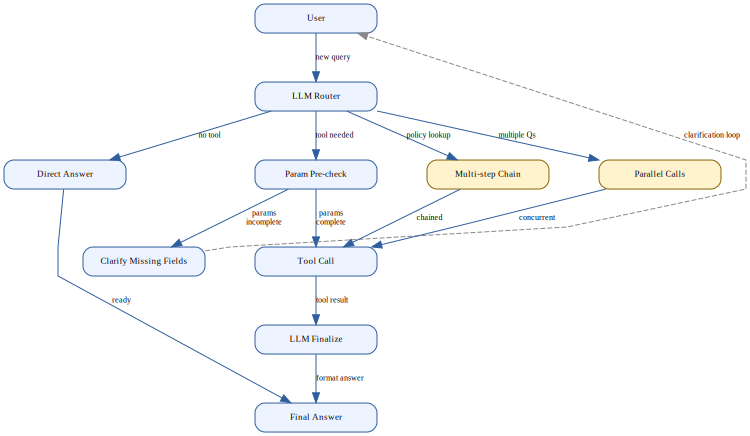

[INFO] Graph rendered via Graphviz.

[INFO] Last 30 lines of vLLM log:
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK
(APIServer pid=1256) INFO:     127.0.0.1:51498 - "POST /v1/chat/completions HTTP/1.1" 200 OK

In [7]:
# 7) Agent flow graph (Stage 3 — includes multi-step + parallel paths)

from IPython.display import display

print("[INFO] Building execution flow graph...")

nodes: Dict[str, str] = {
    "user": "User",
    "llm_router": "LLM Router",
    "direct_answer": "Direct Answer",
    "precheck": "Param Pre-check",
    "clarify": "Clarify Missing Fields",
    "tool_call": "Tool Call",
    "multi_step": "Multi-step Chain",
    "parallel": "Parallel Calls",
    "llm_finalize": "LLM Finalize",
    "final": "Final Answer",
}

edges: List[tuple] = [
    ("user", "llm_router", "new query"),
    ("llm_router", "direct_answer", "no tool needed"),
    ("direct_answer", "final", "ready"),
    ("llm_router", "precheck", "tool needed"),
    ("precheck", "clarify", "params incomplete"),
    ("clarify", "user", "clarification loop"),
    ("precheck", "tool_call", "params complete"),
    ("llm_router", "multi_step", "policy lookup"),
    ("multi_step", "tool_call", "chained call"),
    ("llm_router", "parallel", "multiple questions"),
    ("parallel", "tool_call", "concurrent calls"),
    ("tool_call", "llm_finalize", "tool result"),
    ("llm_finalize", "final", "format answer"),
]

rendered: bool = False

try:
    from graphviz import Digraph

    dot = Digraph(comment="Stage 3 Agent Flow", format="svg")
    dot.attr(rankdir="TB", fontsize="10", nodesep="0.7", ranksep="0.55", splines="polyline")
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#EDF3FF",
             color="#2F5E9E", fontsize="9", width="1.7", height="0.4",
             margin="0.10,0.05")
    dot.attr("edge", color="#2F5E9E", fontsize="8")

    # Create nodes
    for node_id, label in nodes.items():
        if node_id in ("multi_step", "parallel"):
            dot.node(node_id, label, fillcolor="#FFF3CD", color="#856404")
        else:
            dot.node(node_id, label)

    # --- rank constraints for clean vertical layers ---
    with dot.subgraph() as s:
        s.attr(rank="same")
        s.node("direct_answer")
        s.node("precheck")
        s.node("multi_step")
        s.node("parallel")

    with dot.subgraph() as s:
        s.attr(rank="same")
        s.node("clarify")
        s.node("tool_call")

    # --- edges with weight hints ---
    dot.edge("user", "llm_router", label="new query", weight="10")
    dot.edge("llm_router", "precheck", label="tool needed", weight="5")
    dot.edge("llm_router", "direct_answer", label="no tool")
    dot.edge("llm_router", "multi_step", label="policy lookup")
    dot.edge("llm_router", "parallel", label="multiple Qs")
    dot.edge("direct_answer", "final", label="ready")
    dot.edge("precheck", "clarify", label="params\nincomplete")
    dot.edge("precheck", "tool_call", label="params\ncomplete", weight="5")
    dot.edge("multi_step", "tool_call", label="chained")
    dot.edge("parallel", "tool_call", label="concurrent")
    dot.edge("clarify", "user", label="clarification loop",
             constraint="false", style="dashed", color="#888888")
    dot.edge("tool_call", "llm_finalize", label="tool result", weight="5")
    dot.edge("llm_finalize", "final", label="format answer", weight="5")

    display(dot)
    rendered = True
    print("[INFO] Graph rendered via Graphviz.")

except Exception as e:
    print(f"[WARN] Graphviz unavailable ({e}). Falling back to NetworkX.")

if not rendered:
    import matplotlib.pyplot as plt
    import networkx as nx

    graph = nx.DiGraph()
    for node_id, label in nodes.items():
        graph.add_node(node_id, label=label)
    for src, dst, lbl in edges:
        graph.add_edge(src, dst, label=lbl)

    positions: Dict[str, tuple] = {
        "user":           ( 0.5, 7.0),
        "llm_router":     ( 0.5, 5.8),
        "direct_answer":  (-3.0, 4.3),
        "precheck":       (-0.5, 4.3),
        "multi_step":     ( 2.0, 4.3),
        "parallel":       ( 4.0, 4.3),
        "clarify":        (-2.0, 2.8),
        "tool_call":      ( 1.5, 2.8),
        "llm_finalize":   ( 0.5, 1.3),
        "final":          ( 0.5, 0.0),
    }

    node_colors: List[str] = []
    for n in graph.nodes():
        if n in ("multi_step", "parallel"):
            node_colors.append("#FFF3CD")
        else:
            node_colors.append("#EDF3FF")

    plt.figure(figsize=(10.0, 10.0))
    nx.draw_networkx_nodes(
        graph, positions, node_size=2600, node_color=node_colors,
        edgecolors="#2F5E9E", linewidths=1.25,
    )
    nx.draw_networkx_edges(
        graph, positions, arrows=True, arrowstyle="->", arrowsize=14,
        edge_color="#2F5E9E", width=1.35,
        connectionstyle="arc3,rad=0.08",
    )

    node_labels = {n: d["label"] for n, d in graph.nodes(data=True)}
    nx.draw_networkx_labels(graph, positions, labels=node_labels, font_size=8)

    edge_labels = {(u, v): d["label"] for u, v, d in graph.edges(data=True)}
    nx.draw_networkx_edge_labels(graph, positions, edge_labels=edge_labels,
                                  font_size=7, rotate=False)

    plt.title("Stage 3 Agent Flow (multi-step + parallel)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    print("[INFO] Graph rendered via NetworkX fallback.")

print("\n[INFO] Last 30 lines of vLLM log:")
try:
    with open("vllm_server.log", "r", encoding="utf-8") as f:
        lines = f.readlines()[-30:]
    print("".join(lines))
except Exception as e:
    print(f"[ERROR] Could not read vllm_server.log: {e}")
